# TCR data exploration

Here some basic manual exploration of the TCR data is done.

## Data structure:

**Sequence Information:**
- *nSeqFR1-4, nSeqCDR1-3:* Nucleotide sequences of Framework Regions (FR) and Complementarity Determining Regions (CDR)
- *aaSeqFR1-4, aaSeqCDR1-3:* Amino acid sequences of the same regions
- *targetSequences:* The full target sequence

**Clone Metrics:**
- *cloneId:* Unique identifier for each clone
- *readCount:* Number of reads supporting this clone
- *uniqueMoleculeCount:* Number of unique molecules (UMIs)

**V(D)J Gene Usage:**
- *allVHitsWithScore:* Which V genes were used
- *allDHitsWithScore:* Which D genes were used
- *allJHitsWithScore:* Which J genes were used

**Quality Metrics**
- *minQualFR1-4, minQualCDR1-3:* Quality scores for each region

In [1]:
setwd("/scratch_isilon/groups/singlecell/shared/projects/covid-pascual-reguant")

## Libraries

In [2]:
library(glue)
library(here)
library(tidyverse)
library(tidytext)
library(patchwork)
library(ggh4x)
library(scRepertoire)
library(immunarch)

here() starts at /scratch_isilon/groups/singlecell/shared/projects/covid-pascual-reguant

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: immundata

Loading required package: duckplyr

The duckplyr package is configured to fall back to dplyr when it encounters an
incompatibility. Fallback events can be collected and uploaded for analysis to
guide future development. By default, data will be collected but no data will
be uploaded.
ℹ Automatic fallback uploading is not controlled and therefore d

## Parameters

In [3]:
source(here::here("misc/paths.R"))

Rows: 20 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (17): donor_id, study_id, disease_group, sex, age, sars-cov-2_antemortem...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Load data

In [4]:
tcr_data <- "{tcr_data}" %>% glue() %>% here()
out <- "~/SP-COVID/TCR/out"

files <- list.files(tcr_data, pattern = "*.tsv$", full.names = TRUE)
exclude <- c("SP117_055", "SP117_056", "SP117_058")

files <- files[!sapply(files, function(file) {
  any(sapply(exclude, function(pattern) grepl(pattern, file)))
})]

for (file_path in files) {
    data <- read_tsv(file_path, show_col_types = FALSE)
    data <- data %>%
                mutate(topChains = case_when(
                    grepl("TRAV", allVHitsWithScore, ignore.case = TRUE) ~ "TRA",
                    grepl("TRBV", allVHitsWithScore, ignore.case = TRUE) ~ "TRB",
                    TRUE ~ NA_character_))
    output_file <- file.path(out, basename(file_path))
    write_tsv(data, output_file)
}

In [5]:
orig <- basename(files) %>%
        gsub("mixcr_", "", .) %>%
        gsub("_TCR.clones.tsv", "", .) %>%
        gsub(".clones.tsv", "", .)

cond_tissue <- orig %>%
    purrr::map_chr(~ sample_metadata %>%
    dplyr::filter(tcr_id == .x) %>%
    dplyr::pull(study_id_tissue)) 

cond <- sub("_.*", "", cond_tissue)

tissue <- sub(".*[0-9]-", "", cond_tissue)

First, we will read the data using the `loadContigs()` function.

In [2]:
contig.list <- loadContigs(input = out, 
                           format = "MiXCR")

ERROR: Error in loadContigs(input = out, format = "MiXCR"): could not find function "loadContigs"


The processed data, will be used as `combineTCR()` input to merge the multiple TCR contig annotation files into a single standardized object suitable for downstream clonotype analysis. Within each sample, all rows sharing the same barcode are assumed to come from the same cell and are collapsed together; the function does not enforce one chain per type, so multiple alpha or beta chains for a single barcode are retained and represented jointly. 

From these per-barcode aggregates, clonotype calling can be based on the **gene** (VDJC genes comprising the TCR/Ig), **nt** (CDR3 nucleotide sequence), **aa** (CDR3 amino acid sequence), or **strict** (VDJC + nt) that is the proper definition of clonotype ([PubMed: 19568742](https://pubmed.ncbi.nlm.nih.gov/19568742/)).

Additionally, the clonotype call is trying to incorporate both loci (both TCRA and TCRB chains) and if a single cell barcode has multiple sequences identified. There is the possibility to have a subset of barcodes that only return one of the immune receptor chains. The unreturned chain is assigned an NA value.

In [7]:
# removeNA: This will remove any chain without values.
# removeMulti: This will remove barcodes with greater than 2 chains.
# filterMulti: This option will allow for the selection of the 2 corresponding chains with the highest expression for a single barcode.
tcr <- combineTCR(contig.list, 
                  samples = orig,
                  removeNA = FALSE, 
                  removeMulti = FALSE, 
                  filterMulti = FALSE)

Next, we will add as variables the condition and tissue of each sample.

In [8]:
tcr <- addVariable(tcr, variable.name = "cond_tissue", variables = cond_tissue)
tcr <- addVariable(tcr, variable.name = "condition", variables = cond)
tcr <- addVariable(tcr, variable.name = "tissue", variables = tissue)

Lastly, we also export the data into a dataframe tailored for compatibility with the `immunarch` package, that we will use for some specific analysis.

In [9]:
imm <- scRepertoire::exportClones(tcr, write.file = FALSE,
    format = "immunarch")
imm$meta$condition <- cond
imm$meta$tissue <- tissue
imm$meta$cond_tissue <- cond_tissue

## Basic clonal analysis

Now, we can start by looking at the total number of clonotypes in each sample.

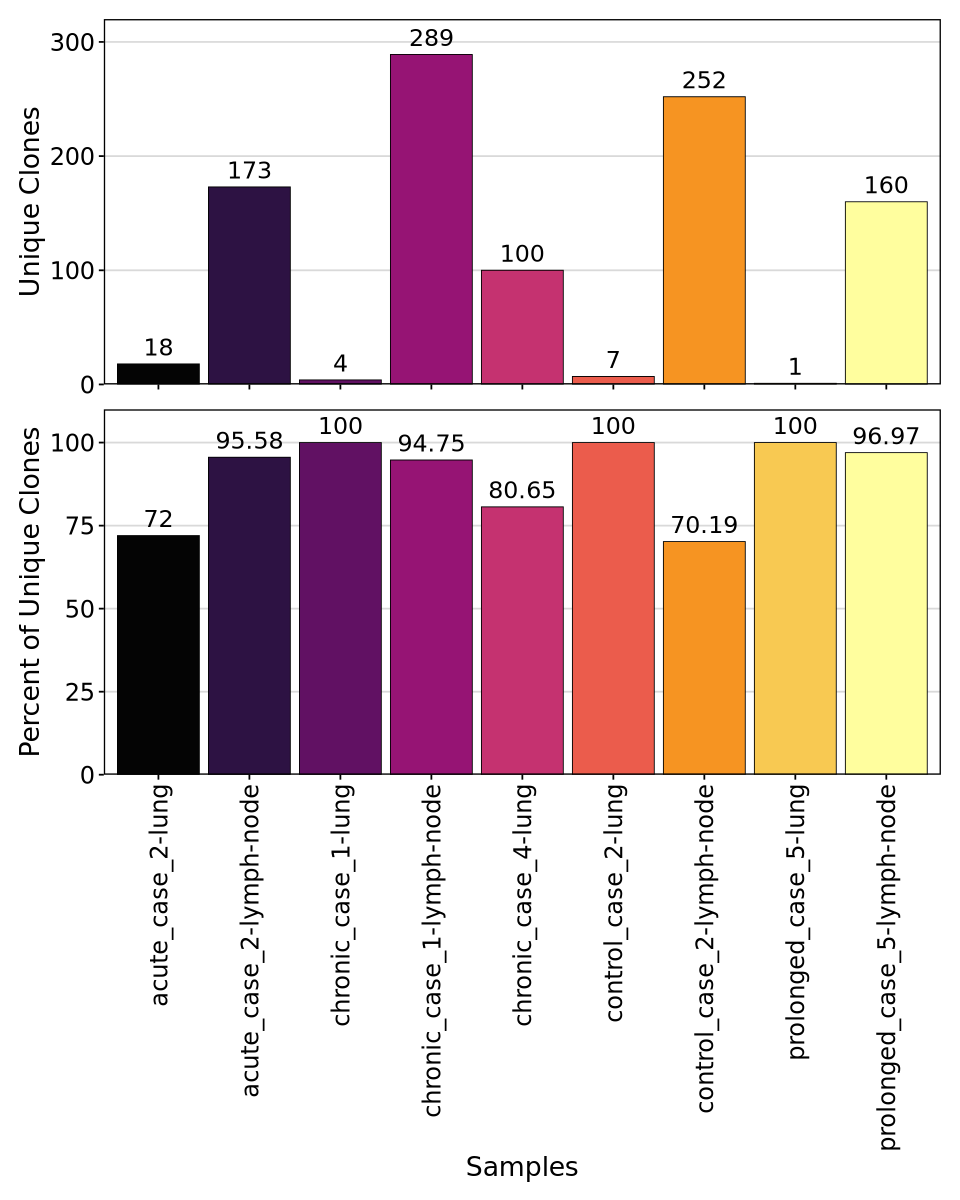

In [11]:
options(repr.plot.width = 8, repr.plot.height = 10, warn = -1)

p1 <- clonalQuant(tcr, cloneCall = "strict", chain = "both", scale = FALSE, group.by = "cond_tissue") +
        geom_text(aes(label = contigs, y = contigs), vjust = -0.5, color = "black", size = 5) +
        scale_y_continuous(limits = c(0, 320), expand = expansion(mult = c(0, 0))) +
        theme(legend.position = "none", 
              text = element_text(size = 16), 
              axis.text.x = element_blank(), 
              axis.title.x = element_blank())

p2 <- clonalQuant(tcr, cloneCall = "strict", chain = "both", scale = TRUE, group.by = "cond_tissue") +
        geom_text(aes(label = round(scaled, 2), y = scaled), vjust = -0.5, color = "black", size = 5) +
        scale_y_continuous(limits = c(0, 110), expand = expansion(mult = c(0, 0))) +
        theme(legend.position = "none",
              text = element_text(size = 16),
              axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

p1 / p2

We can do the same by tissue, we can see that we have more unique clonotyes in lymph-nodes compared to lungs.

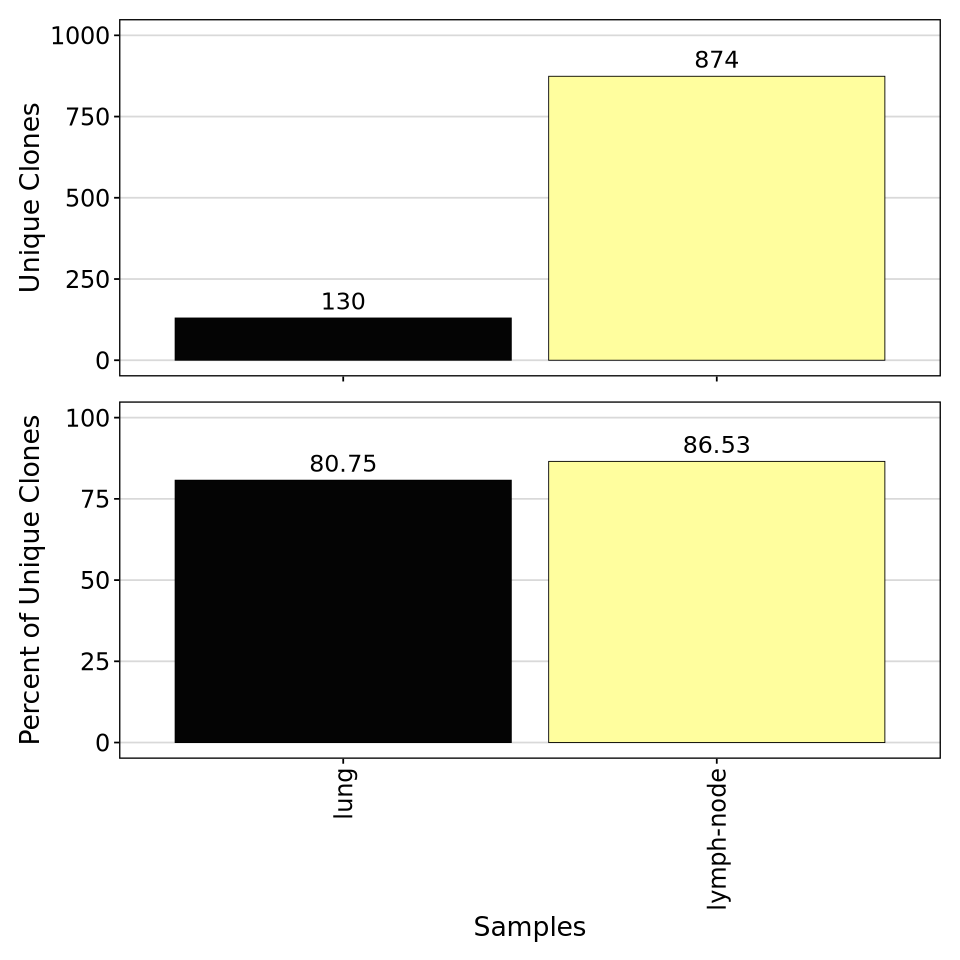

In [12]:
options(repr.plot.width = 8, repr.plot.height = 8, warn = -1)

p1 <- clonalQuant(tcr, cloneCall = "strict", chain = "both", group.by = "tissue", scale = FALSE) +
        geom_text(aes(label = contigs, y = contigs), vjust = -0.5, color = "black", size = 5) +
        coord_cartesian(ylim = c(0, 1000)) +
        theme(legend.position = "none",
              text = element_text(size = 16),
              axis.text.x = element_blank(),
              axis.title.x = element_blank())

p2 <- clonalQuant(tcr, cloneCall = "strict", chain = "both", group.by = "tissue", scale = TRUE) +
        geom_text(aes(label = round(scaled, 2), y = scaled), vjust = -0.5, color = "black", size = 5) +
        coord_cartesian(ylim = c(0, 100)) +
        theme(legend.position = "none",
              text = element_text(size = 16),
              axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

p1 / p2

Finally, we can also check it by disease stage.

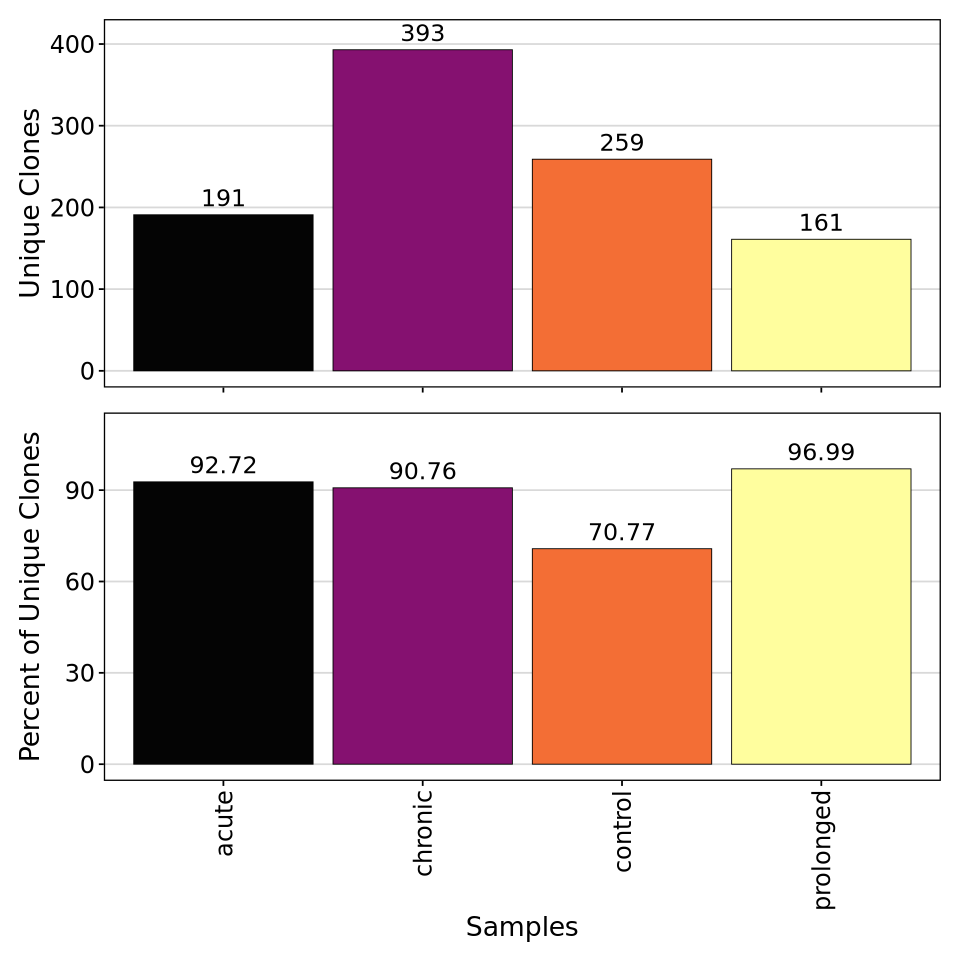

In [27]:
options(repr.plot.width = 8, repr.plot.height = 8, warn = -1)

p1 <-clonalQuant(tcr, cloneCall = "strict", chain = "both", group.by = "condition", scale = FALSE) +
        geom_text(aes(label = contigs, y = contigs), vjust = -0.5, color = "black", size = 5) +
        coord_cartesian(ylim = c(0, 410)) +
        theme(legend.position = "none",
              text = element_text(size = 16),
              axis.text.x = element_blank(),
              axis.title.x = element_blank())
p2 <- clonalQuant(tcr, cloneCall = "strict", chain = "both", group.by = "condition", scale = TRUE) +
        geom_text(aes(label = round(scaled, 2), y = scaled), vjust = -0.5, color = "black", size = 5) +
        coord_cartesian(ylim = c(0, 110)) +
        theme(legend.position = "none",
              text = element_text(size = 16),
              axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))
p1 / p2

Next, we can explore the distribution of sequence lengths by looking at the length distribution of the CDR3 amino acid sequences by chain, and both together. 

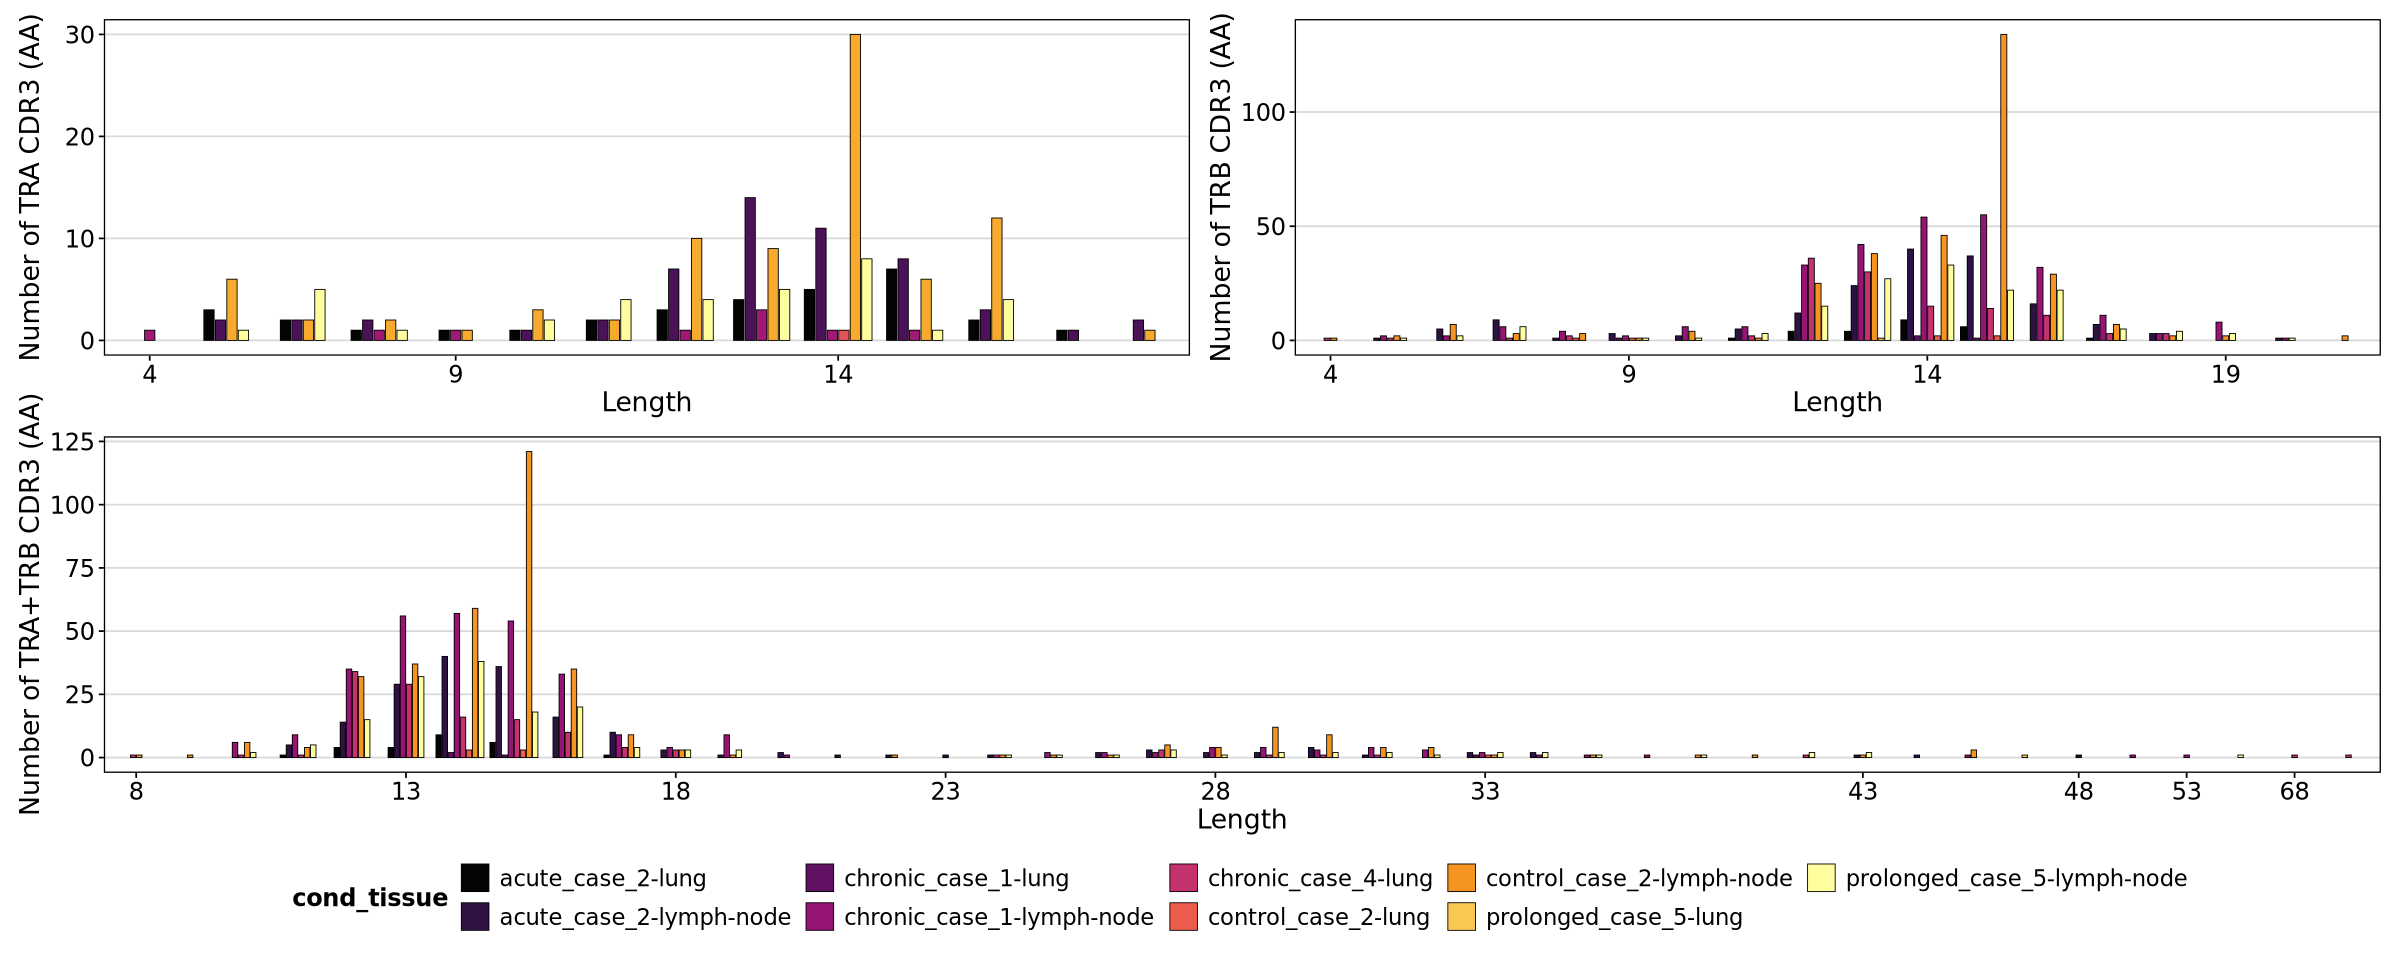

In [14]:
options(repr.plot.width = 20, repr.plot.height = 8, warn = -1)

p1 <- clonalLength(tcr, cloneCall = "aa", chain = "TRA", group.by = "cond_tissue") + 
labs(y = "Number of TRA CDR3 (AA)") +
theme(legend.position = "none", text = element_text(size = 16))

p2 <- clonalLength(tcr, cloneCall = "aa", chain = "TRB", group.by = "cond_tissue")  +  
labs(y = "Number of TRB CDR3 (AA)") +
theme(legend.position = "none", text = element_text(size = 16))

p3 <- clonalLength(tcr, cloneCall = "aa", group.by = "cond_tissue") +
labs(y = "Number of TRA+TRB CDR3 (AA)") +
theme(legend.position = "bottom", text = element_text(size = 16)) 

(p1 | p2) / p3

## Repertoires summary

To summarize CDR3 sequence composition, we will analyze the relative amino-acid usage across all TRB CDR3 sequences using `percentAA()`. This approach quantifies the proportion of each amino acid across the repertoire, providing a global view of biochemical constraints and selection acting on the antigen-recognition region. It provides insights into the amino acid composition and variability at each residue, which can be indicative of functional constraints or selection pressures on the CDR3

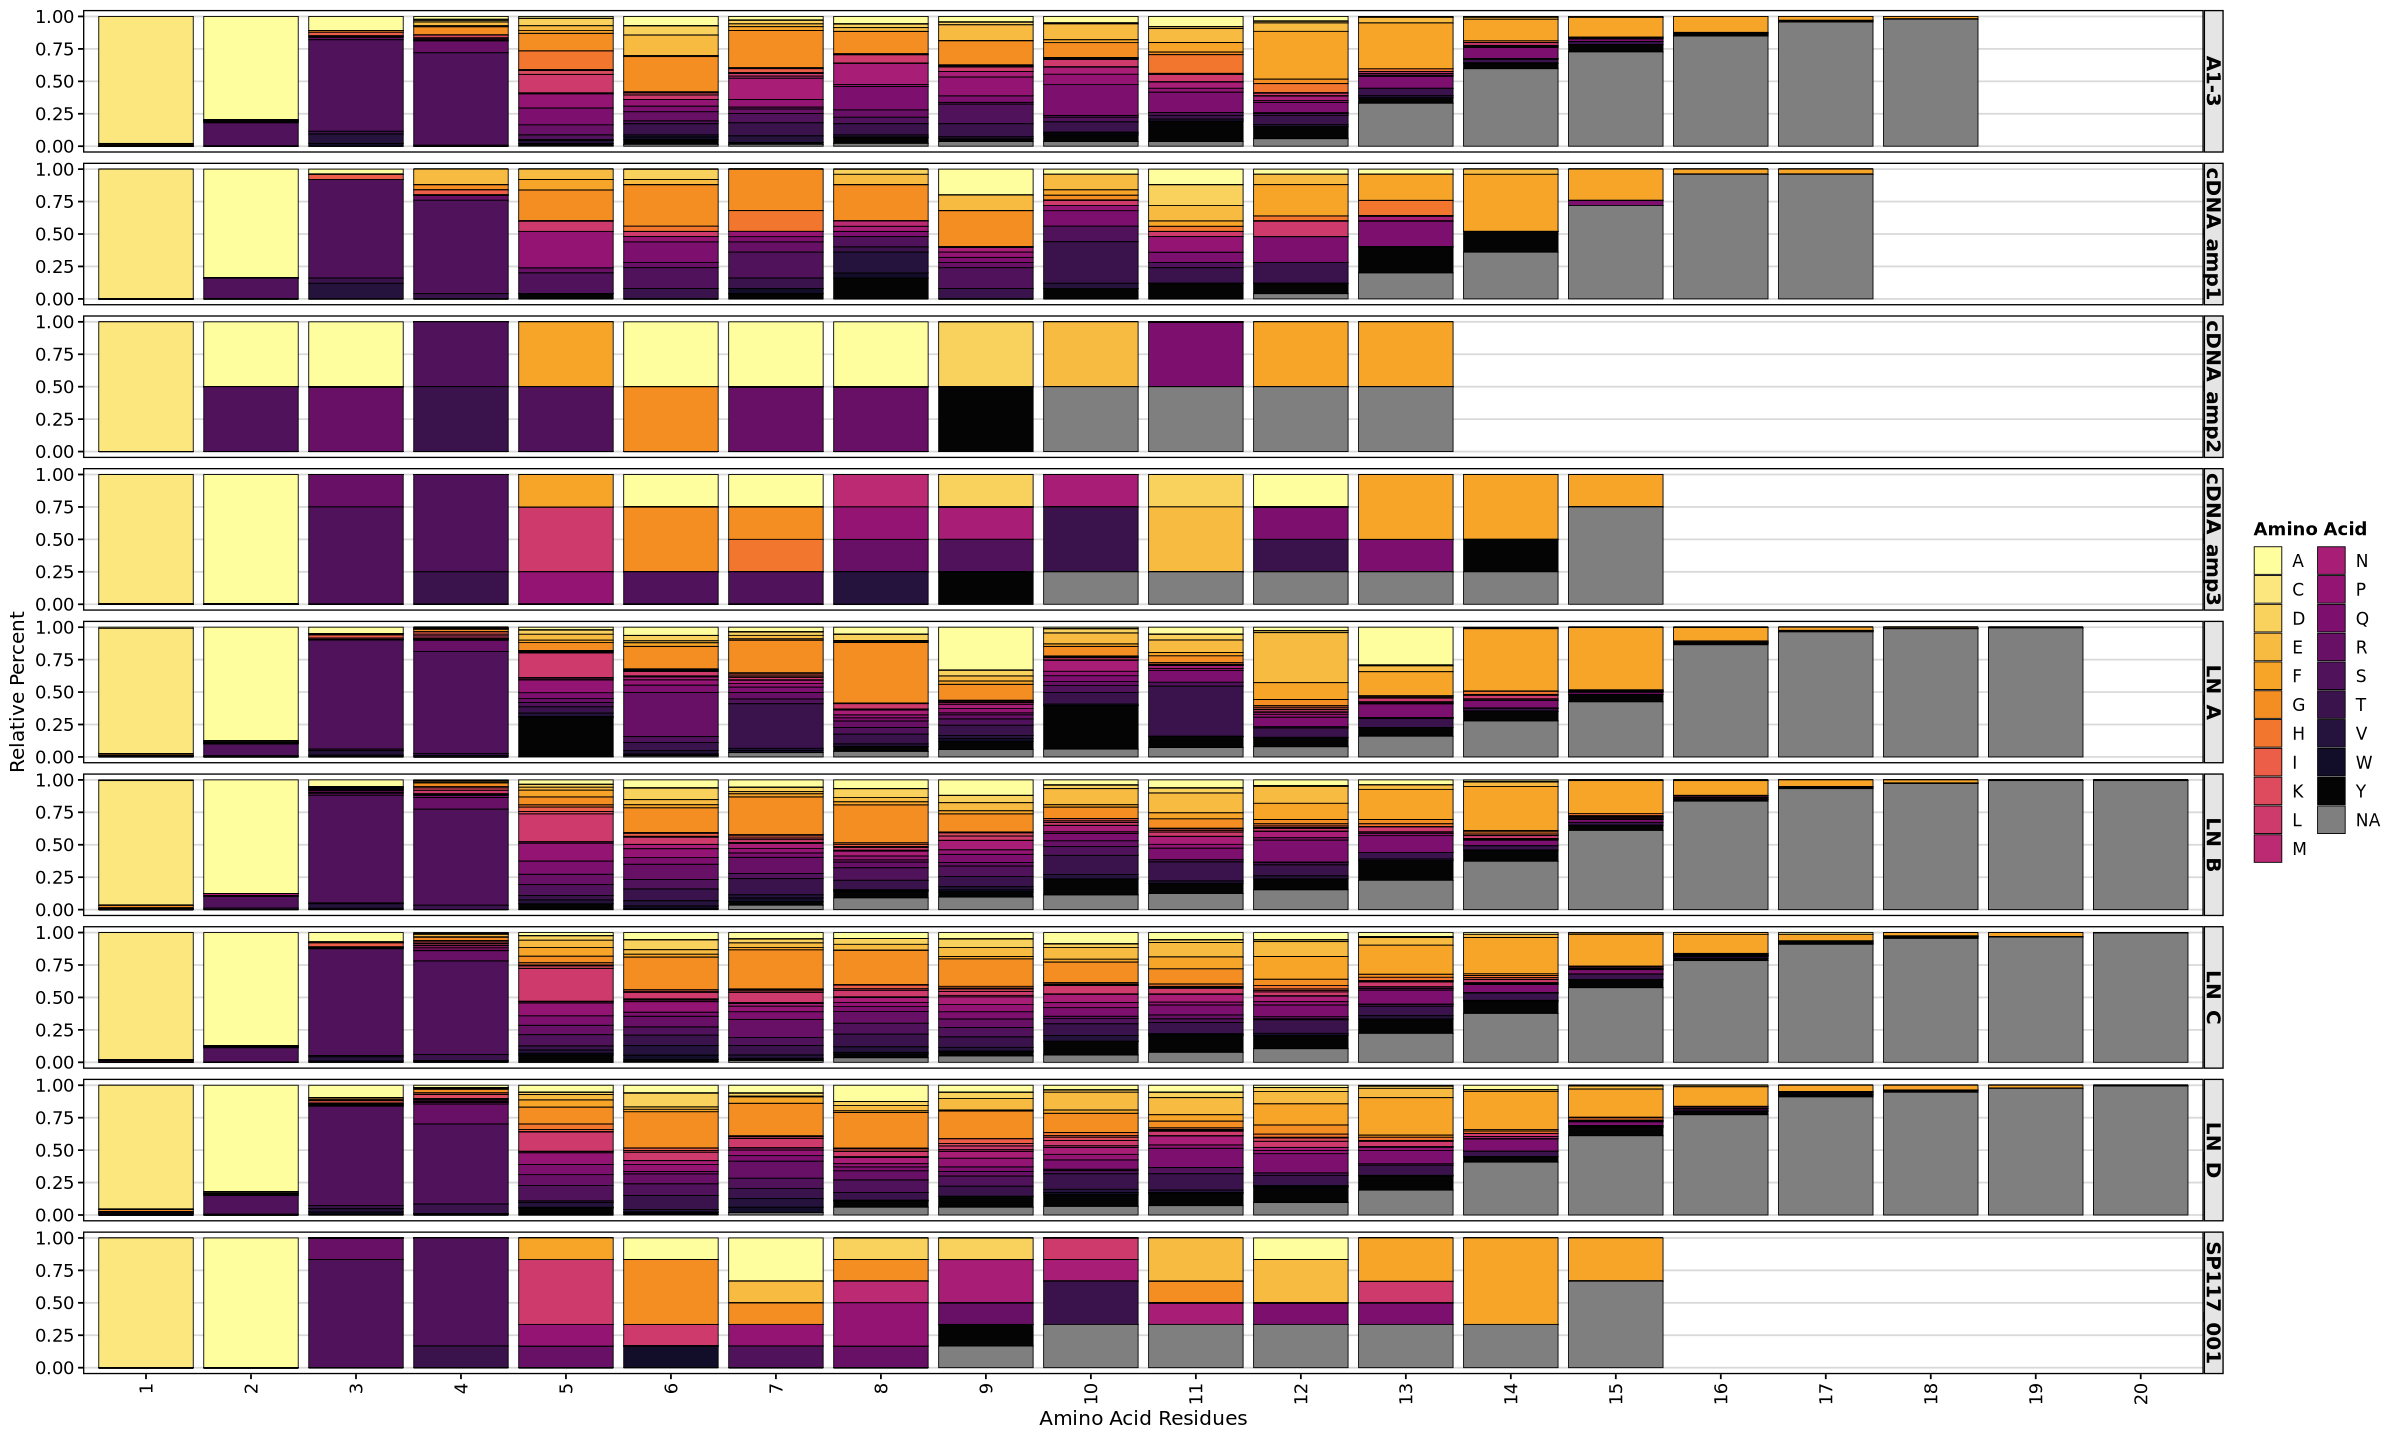

In [15]:
options(repr.plot.width = 20, repr.plot.height = 12, warn = -1)

percentAA(tcr, chain = "TRB") + theme(text = element_text(size = 12)) 

## Clonal diversity

Clonal diversity can be quantified at the level of individual samples or after grouping samples by biological variables. In this analysis, diversity was computed by disease stage, allowing direct comparison of repertoire complexity across experimental groups rather than across single samples. This approach reduces the impact of per-sample sparsity and sequencing depth variability, and yields more interpretable distributions for diversity metrics.
Using `clonalDiversity()`, we quantify overall TCR repertoire complexity under different clonotype definitions by summarizing how many clonotypes are present and how evenly they are distributed. To capture complementary aspects of diversity, we use the following Hill number–based metrics:

| Metric | Definition | Range | Higher values indicate... |
|-------|------------|-------|----------------|
| **hill0** | Richness (Hill number q = 0); the total number of unique clonotypes observed in the sample. | 0 → ∞ | **more unique clonotypes** (greater raw richness). |
| **hill1** | Effective number of abundant clonotypes (Hill number q = 1); equal to the exponential of Shannon entropy. | 1 → ∞ | **greater diversity** of common clonotypes, balancing richness and evenness. |
| **hill2** | Effective number of dominant clonotypes (Hill number q = 2); equivalent to the inverse Simpson index. | 1 → ∞ | **greater diversity** among the most dominant clonotypes in the repertoire. |

Together, these metrics provide a multi-scale view of clonal diversity, ranging from total clonotype richness to the dominance structure of the most expanded clones.


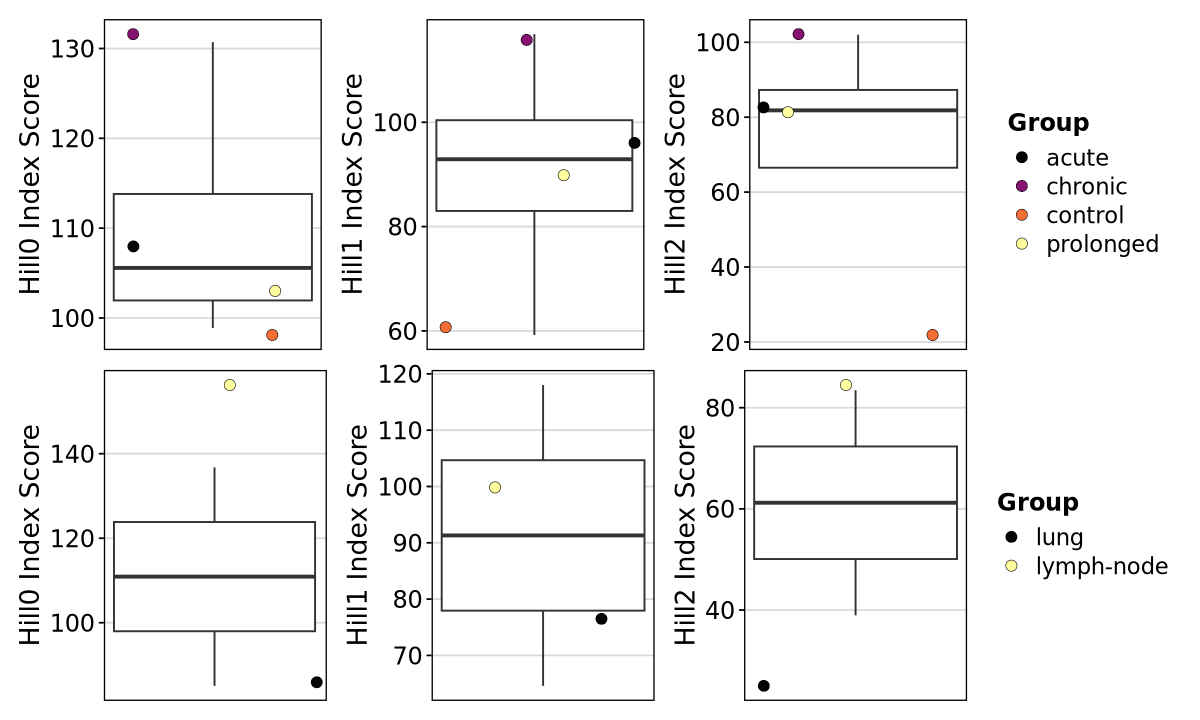

In [16]:
options(repr.plot.width = 10, repr.plot.height = 6, warn = -1)

p1 <- clonalDiversity(tcr, cloneCall = "strict", metric = "hill0", group.by = "condition") + theme(legend.position = "none", text = element_text(size = 16)) 
p2 <- clonalDiversity(tcr, cloneCall = "strict", metric = "hill1", group.by = "condition") + theme(legend.position = "none", text = element_text(size = 16))
p3 <- clonalDiversity(tcr, cloneCall = "strict", metric = "hill2", group.by = "condition") + theme(text = element_text(size = 16))

p4 <- clonalDiversity(tcr, cloneCall = "strict", metric = "hill0", group.by = "tissue") + theme(legend.position = "none", text = element_text(size = 16)) 
p5 <- clonalDiversity(tcr, cloneCall = "strict", metric = "hill1", group.by = "tissue") + theme(legend.position = "none", text = element_text(size = 16))
p6 <- clonalDiversity(tcr, cloneCall = "strict", metric = "hill2", group.by = "tissue") + theme(text = element_text(size = 16))


(p1 | p2 | p3) /
(p4 | p5 | p6)

For Hill0, which measures raw clonotype richness, shows greater dispersion and clearer separation between conditions. Chronic samples exhibit the highest richness, indicating a larger total number of distinct clonotypes, while control samples cluster at lower values, consistent with a more restricted repertoire. 

For Hill1, reflecting the effective number of abundant clonotypes, chronic samples tend to show higher values, suggesting a more even distribution among frequently expanded clonotypes, whereas control samples consistently display lower values, indicative of reduced clonal complexity.

Hill2, which emphasizes dominant clonotypes, reveals the strongest contrast between conditions. Control samples show markedly reduced diversity, indicating domination by a small number of expanded clones. In contrast, acute, prolonged, and especially chronic conditions maintain higher Hill2 values, reflecting a broader distribution among dominant clonotypes and reduced clonal skewing.

Regarding diversity across tisues, lymph-nodes present higher Hill numbers overal, indicating greater diversity.

## Clonal dynamics 

### Examination of the clonal space

By examining the clonal space, we effectively look at the relative space occupied by clones at specific proportions. 
`clonalHomeostasis()` provides an assessment of how different “sizes” of clones (based on their proportional abundance) contribute to the overall repertoire. This visualization helps to identify shifts in repertoire structure, such as expansion of large clones in response to infection or contraction in chronic conditions, offering insights into immune system activity and health.

Like clonal space homeostasis, `clonalProportion()` also categorizes clones into separate bins. The key difference is that instead of looking at the relative proportion of the clone to the total, `clonalProportion()`ranks the clones by their total count or frequency of occurrence and then places them into predefined bins.

`clonalProportion()` complements `clonalHomeostasis()` by providing a perspective on how the “richest” (most abundant) clones contribute to the overall repertoire space. By segmenting clones into rank-based bins, it helps identify whether a few highly expanded clones or a larger number of moderately expanded clones dominate the immune response, offering distinct insights into repertoire structure and dynamics.

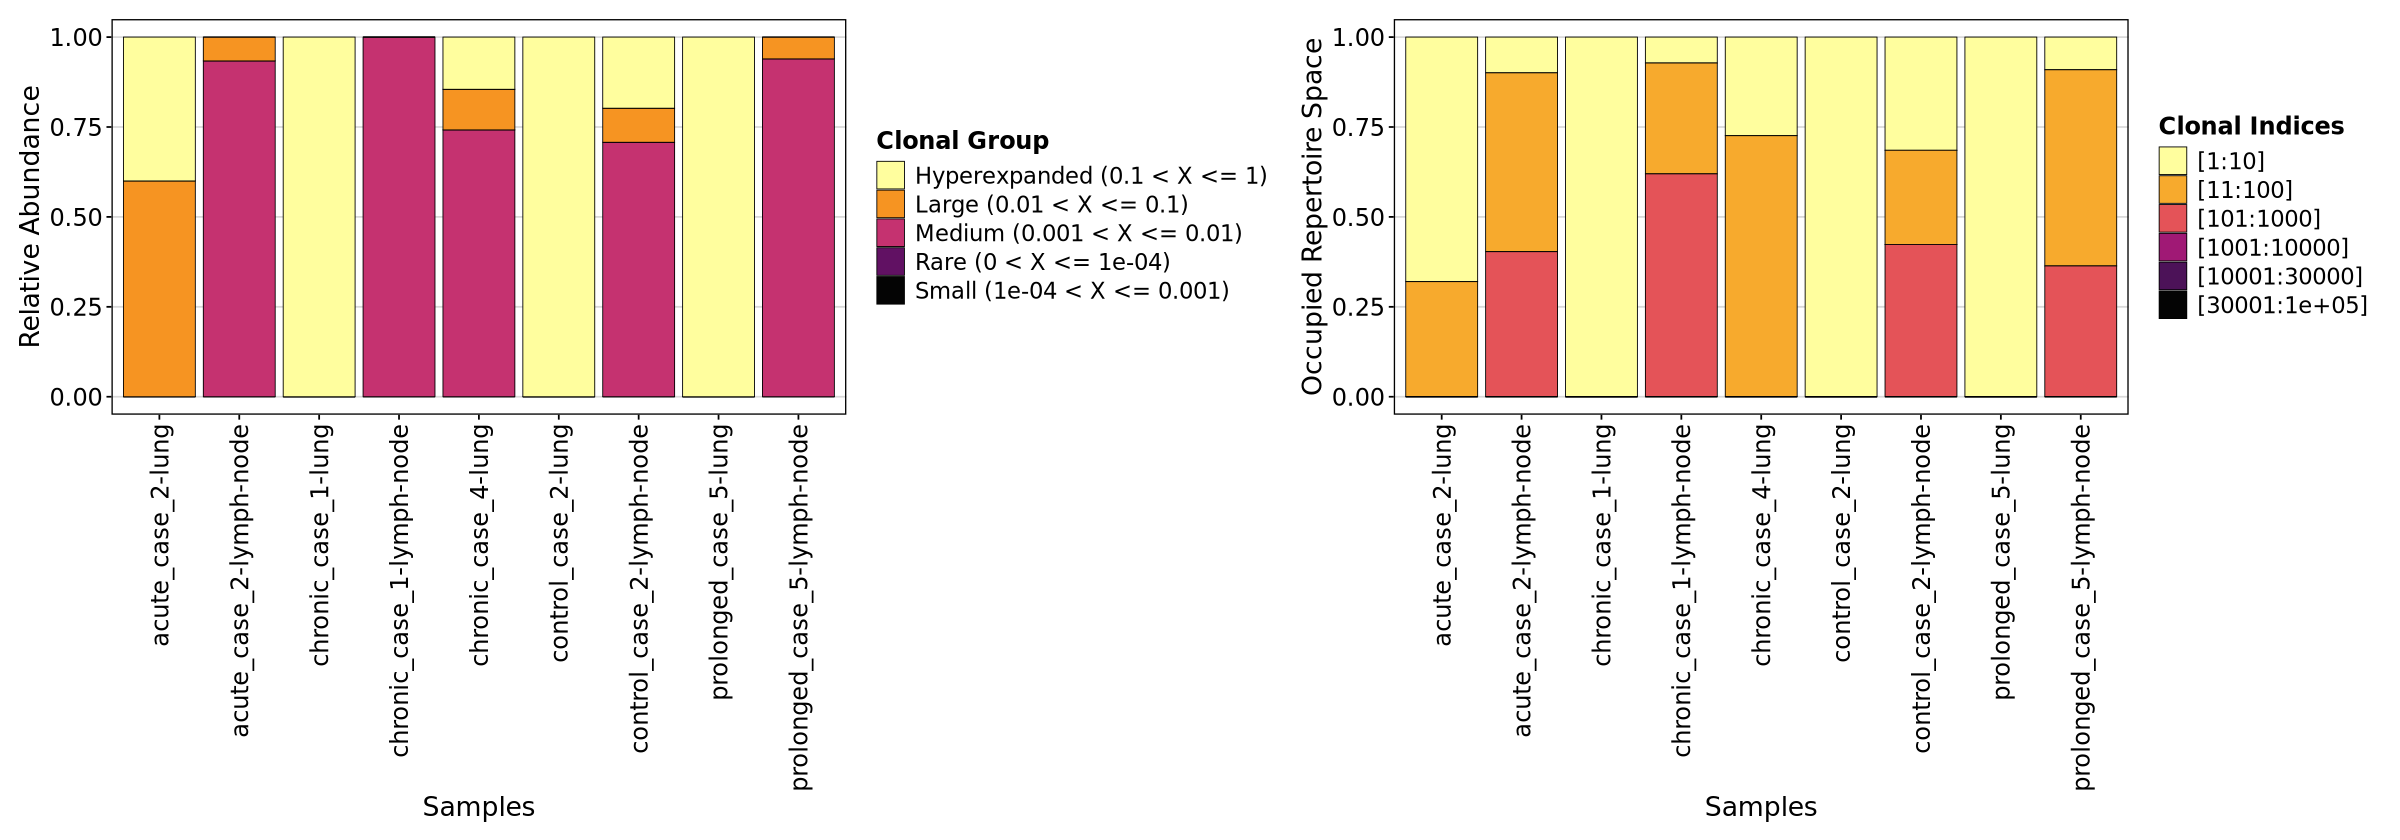

In [17]:
options(repr.plot.width = 20, repr.plot.height = 7, warn = -1)

p1 <- clonalHomeostasis(tcr, cloneCall = "strict", group.by = "cond_tissue") +
theme(text = element_text(size = 16), axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))
p2 <- clonalProportion(tcr, cloneCall = "strict", group.by = "cond_tissue") +
theme(text = element_text(size = 16), axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

p1 | p2

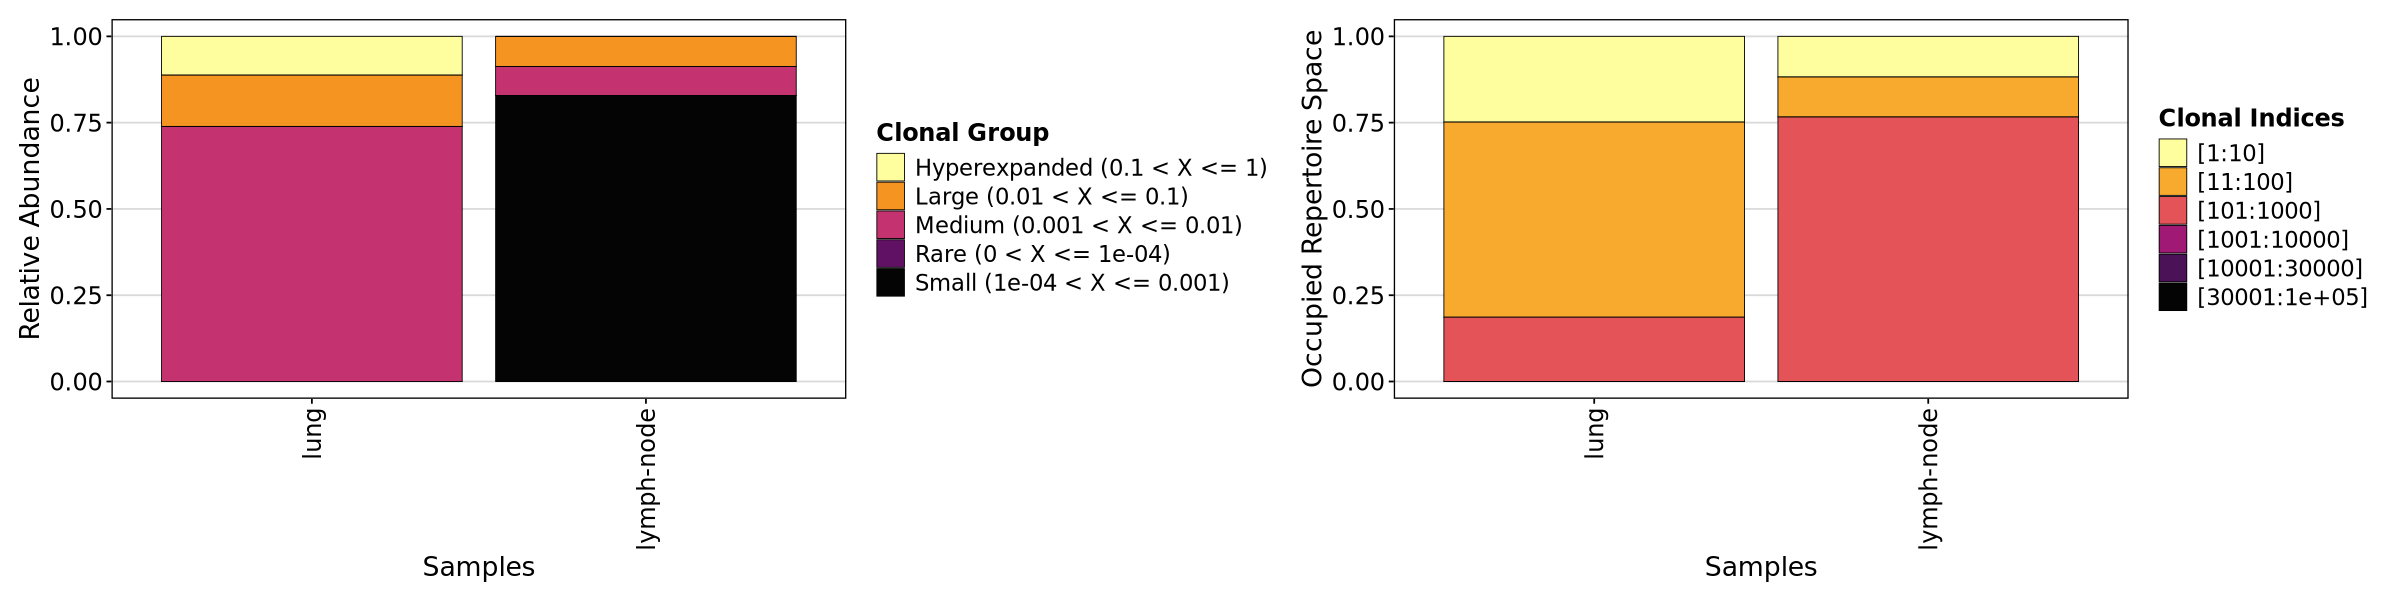

In [18]:
options(repr.plot.width = 20, repr.plot.height = 5, warn = -1)

p1 <- clonalHomeostasis(tcr, cloneCall = "strict", group.by = "tissue") +
theme(text = element_text(size = 16), axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))
p2 <- clonalProportion(tcr, cloneCall = "strict", group.by = "tissue") +
theme(text = element_text(size = 16), axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

p1 | p2

The clonal homeostasis and proportion analyses reveal the dynamics of T cell expansion from lymph nodes to infected lung tissue in COVID-19 patients, though interpretation is limited by severe undersampling of lung specimens.

In lymph nodes, which serve as primary sites for T cell priming and activation, individual samples show oligoclonal patterns where a subset of antigen-specific clones has undergone moderate expansion. Each patient displays unique expanded clones, with the top 100 clones accounting for 60-90% of the lymph node repertoire. The high clones-per-spot ratios of 0.95-0.97 indicate that while a few clones dominate by cell number, most clones remain rare, reflecting the initial diversification of the adaptive immune response during T cell priming. When lymph node samples are aggregated across patients, the lack of shared dominant clones becomes apparent, with 85% of clones appearing at very low frequencies.

The lung represents the secondary infection site where primed T cells traffic to combat active SARS-CoV-2 replication. However, only one lung sample (chronic_case_4-lung with 124 cells) provides adequate depth for interpretation, rendering their apparent diversity patterns artifactual. The single informative lung sample shows moderate clonal expansion with a clones-per-spot ratio of 0.81, suggesting that specific T cell clones undergo further proliferation upon encountering viral antigens at the infection site. This represents the expected pattern of local clonal expansion where lymph node-primed T cells that recognize viral epitopes preferentially expand in lung tissue.

The data suggest a model where diverse T cell populations are initially activated in lymph nodes with patient-specific clone selection, followed by secondary expansion of antigen-specific clones in the lungs where they encounter SARS-CoV-2. However, the severe undersampling of lung tissue prevents robust conclusions about the magnitude or specificity of this secondary expansion. Proper characterization of lymph node-to-lung clonal dynamics would require lung samples with at least 100-150 cells to match the depth achieved in lymph nodes.

### Clonal dynamics across samples and conditions

Because identical CDR3 amino-acid sequences can arise through convergent recombination and may be encoded by multiple distinct nucleotide rearrangements, aa-defined clonotypes often decompose into several genetically distinct lineages when examined under stricter criteria. For this reason, we used the strict clonotype definition when quantifying total clonotype numbers and repertoire diversity. In contrast, we will now use aa-defined clonotypes for the next clonal dynamics analysis, as amino-acid–level grouping captures functionally similar TCRs that are likely to recognize the same antigens, even when they originate from independent recombination events. This approach enables the identification of functionally similar TCRs that recur across tissues or conditions.

First, using `clonalOverlap()`, we will check for the exact number of overlapping clones between all samples and the Morisita’s overlap index.
Morisita’s overlap index is a frequency-weighted metric that strongly emphasizes abundant clonotypes while being robust to differences in sampling depth. It reflects the probability that two randomly drawn sequences, one from each repertoire, belong to the same clonotype. Morisita’s index is particularly well suited for comparing biological similarity driven by dominant clonal expansions.

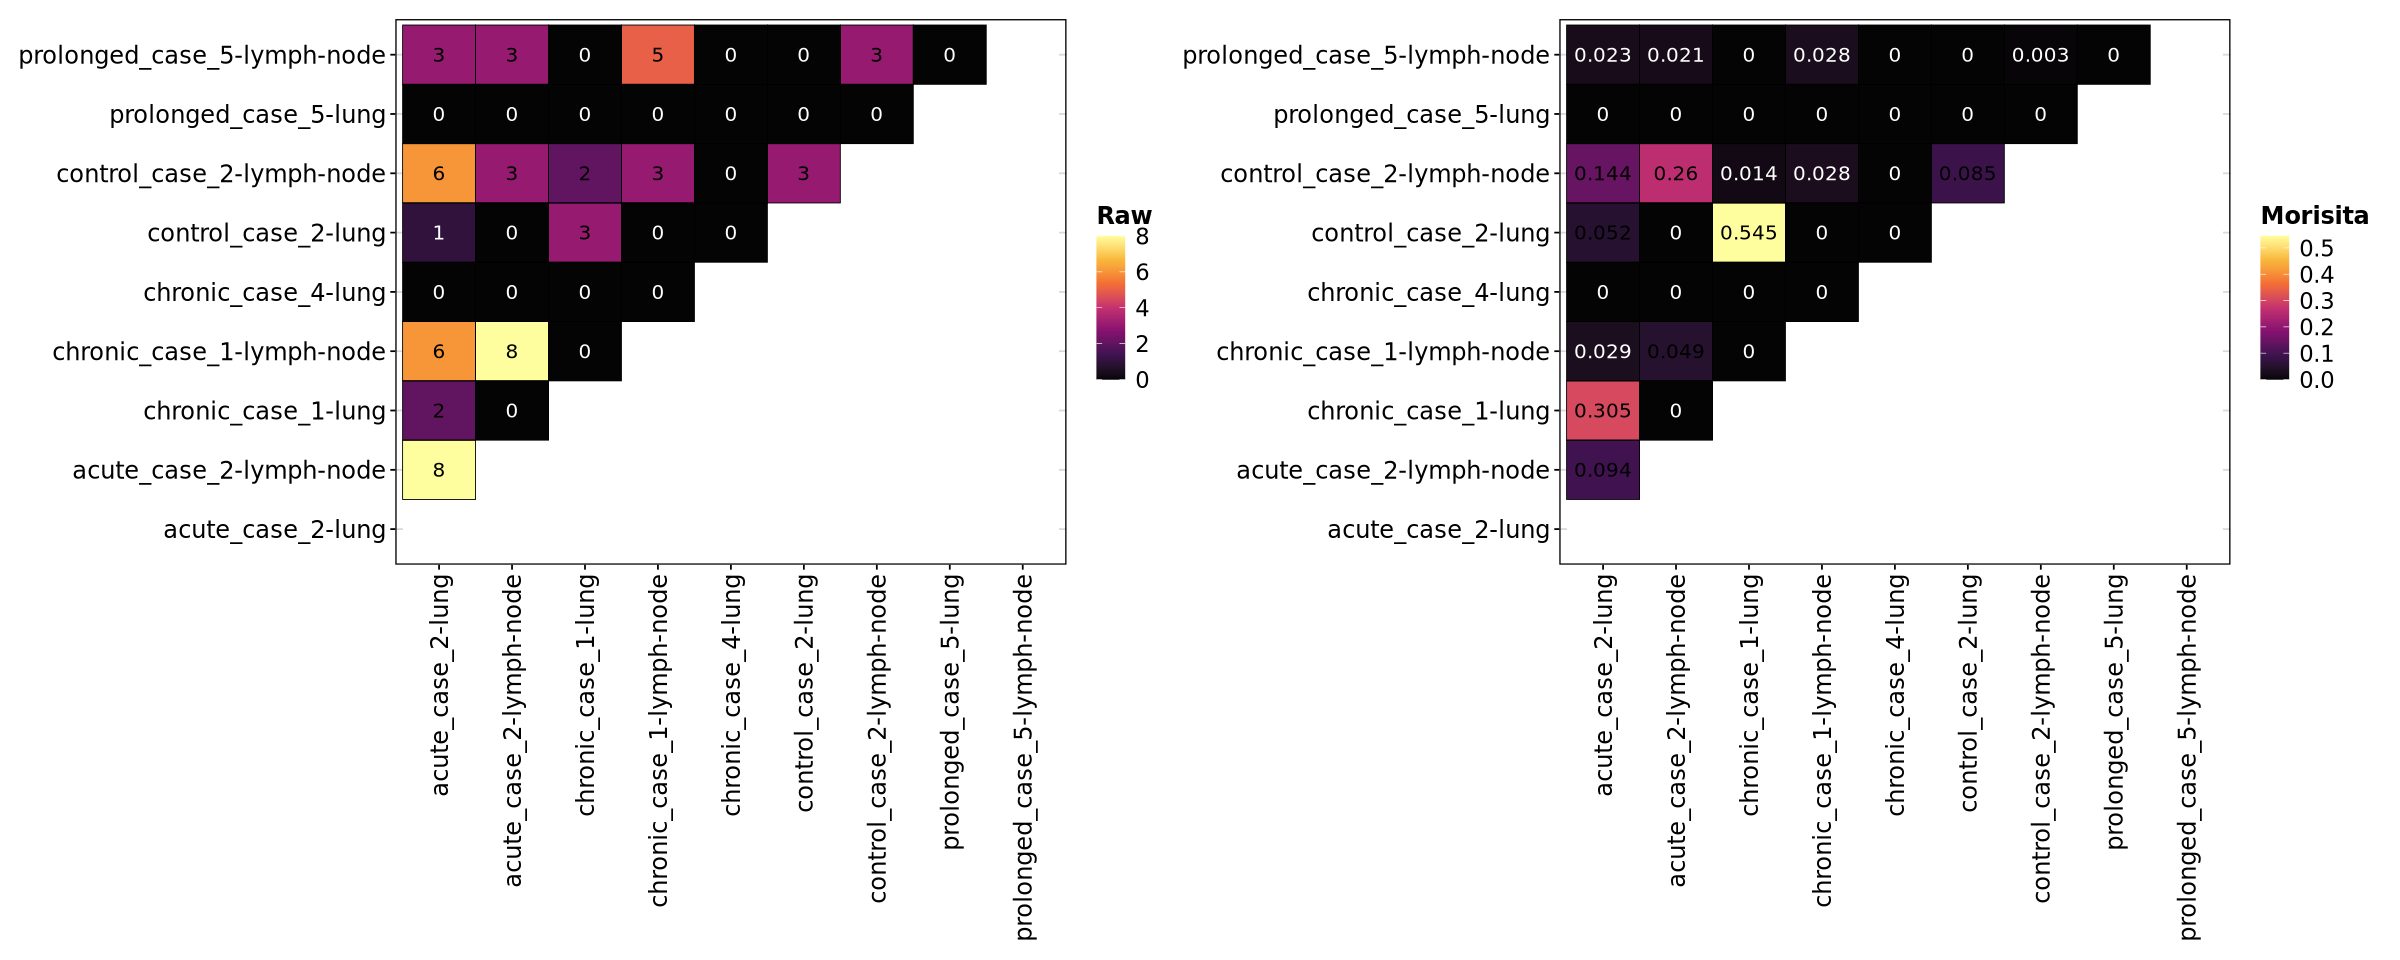

In [19]:
options(repr.plot.width = 20, repr.plot.height = 8, warn = -1)

p1 <- clonalOverlap(tcr, cloneCall = "aa", method = "raw", group.by = "cond_tissue") +
theme(text = element_text(size = 16), axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

p2 <- clonalOverlap(tcr, cloneCall = "aa", method = "morisita", group.by = "cond_tissue") +
theme(text = element_text(size = 16), axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

p1 | p2

We can also check the overlap of clonotypes by condition.

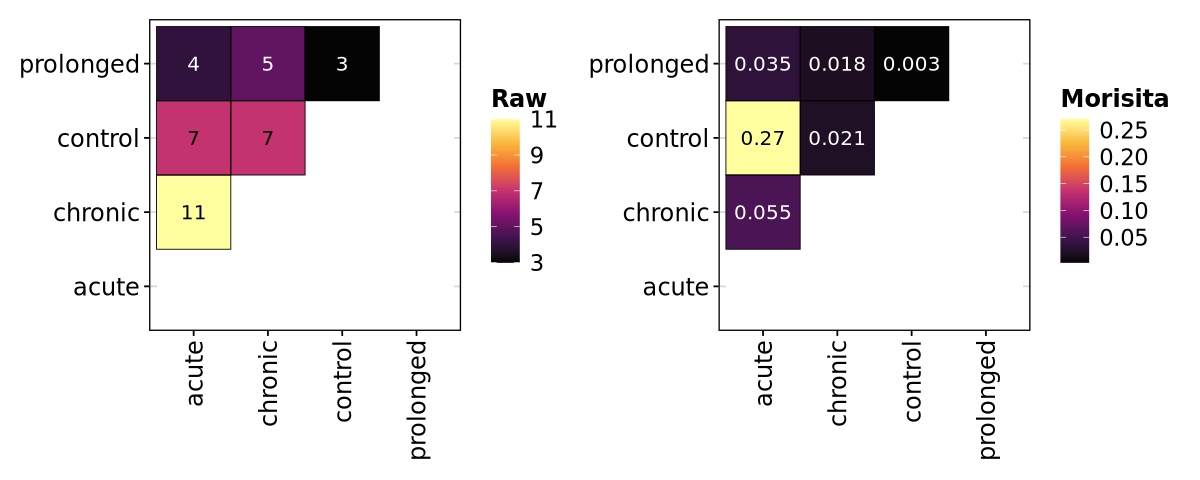

In [20]:
options(repr.plot.width = 10, repr.plot.height = 4, warn = -1)

p1 <- clonalOverlap(tcr, cloneCall = "aa", method = "raw", group.by = "condition") +
theme(text = element_text(size = 16), axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

p2 <- clonalOverlap(tcr, cloneCall = "aa", method = "morisita", group.by = "condition") +
theme(text = element_text(size = 16), axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

p1 | p2

Apparent similarity patterns are driven primarily by lymph-node samples with high clonal richness, while lung samples are too sparsely sampled for reliable overlap estimates; after accounting for clone depth, acute and control conditions show the strongest compositional similarity, whereas prolonged cases display reduced clonal sharing, consistent with clonal contraction or remodeling.

Using `clonalCompare()` we can track the clones proportions changes between tissues from the same patient. We can also look at general changes in clones dynamics across disease stage, by tracking how the proportions of top clones change between the ordered conditions.

First we will focus in clones shared across tissues.

In [21]:
do.call(rbind, tcr) %>%
distinct(CTaa, tissue, cond_tissue) %>%
group_by(CTaa) %>%
summarise(n_tissues = n_distinct(tissue),
          samples = paste(sort(unique(cond_tissue)), collapse = ";"),
          .groups = "drop") %>%
filter(n_tissues > 1) %>%
arrange(desc(n_tissues))

CTaa,n_tissues,samples
<chr>,<int>,<chr>
CVVIPLGGYNKLIF_NA,2,control_case_2-lung;control_case_2-lymph-node
NA_CAISGGREAETQYF,2,acute_case_2-lung;acute_case_2-lymph-node
NA_CASGSGWGAEAFF,2,acute_case_2-lung;acute_case_2-lymph-node;control_case_2-lymph-node;prolonged_case_5-lymph-node
NA_CASSEGGSGTQYF,2,acute_case_2-lung;acute_case_2-lymph-node;chronic_case_1-lymph-node
NA_CASSFGQGAVEQYF,2,acute_case_2-lung;chronic_case_1-lymph-node;prolonged_case_5-lymph-node
NA_CASSLGGPYNEQFF,2,chronic_case_1-lung;control_case_2-lung;control_case_2-lymph-node
NA_CASSPGPDRLNEQFF,2,control_case_2-lung;control_case_2-lymph-node
NA_CASSPSHVSTDTQYF,2,acute_case_2-lung;chronic_case_1-lung;control_case_2-lymph-node
NA_CASSPTGYTYEQYF,2,acute_case_2-lung;acute_case_2-lymph-node;chronic_case_1-lymph-node;control_case_2-lymph-node;prolonged_case_5-lymph-node


Considering that we want to track across tissues in the same patient, we only have shared clones between **control case 2** and **acute case 2**. In both cases we see that shared clonotypes expands in lungs compared to the proportions in lymph nodes.

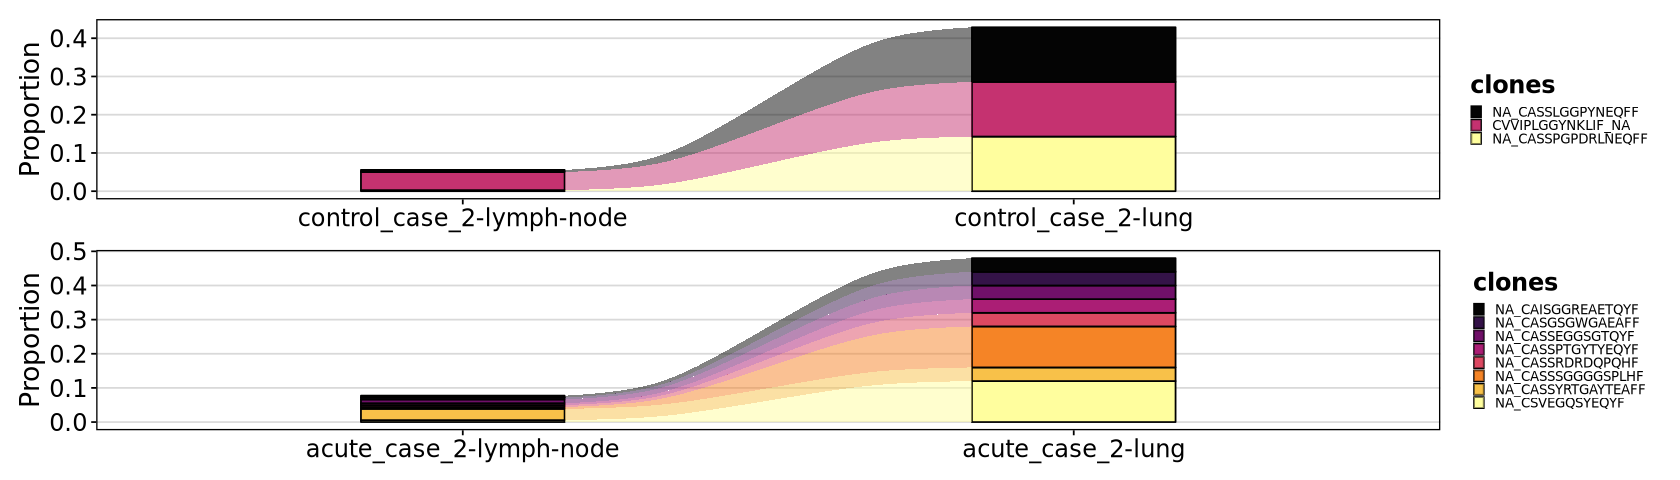

In [23]:
options(repr.plot.width = 14, repr.plot.height = 4, warn = -1)

p1 <- clonalCompare(tcr, cloneCall = "aa", group.by = "cond_tissue",
                    samples = c("control_case_2-lung", "control_case_2-lymph-node"), 
                    order.by = c("control_case_2-lymph-node", "control_case_2-lung"),
                    clones = c("CVVIPLGGYNKLIF_NA", "NA_CASSPGPDRLNEQFF", "NA_CASSLGGPYNEQFF")) +
theme(text = element_text(size = 16))

p2 <- clonalCompare(tcr, cloneCall = "aa", group.by = "cond_tissue",
                    samples = c("acute_case_2-lung","acute_case_2-lymph-node"),
                    order.by = c("acute_case_2-lymph-node", "acute_case_2-lung"),
                    clones = c("NA_CAISGGREAETQYF", "NA_CASGSGWGAEAFF", "NA_CASSEGGSGTQYF", 
                               "NA_CSVEGQSYEQYF", "NA_CASSYRTGAYTEAFF", "NA_CASSPTGYTYEQYF", 
                               "NA_CASSRDRDQPQHF", "NA_CASSSGGGGSPLHF")) +
theme(text = element_text(size = 16))

p1/p2

Next, tracking the shared clones across conditions from all samples, we see that there's a progressive decline in the total proportion of shared clones across disease stages.

In pneumonia patients, these shared clonotypes comprise approximately 22% of the total T cell repertoire, representing a substantial fraction of the immune response. However, this proportion decreases dramatically to roughly 15% during acute COVID-19 infection, despite clear evidence of clonal expansion among specific clonotypes. This paradox suggests that while certain shared clones undergo proliferation in response to SARS-CoV-2, they are simultaneously diluted by an even more substantial expansion of novel, COVID-specific clonotypes not present in the pneumonia baseline.
The chronic COVID-19 phase shows the most dramatic shift, with shared clones representing only approximately 4% of the total repertoire. This severe contraction indicates that the T cell response has become increasingly dominated by clonotypes unique to this stage, potentially reflecting ongoing viral persistence, tissue-specific responses, or the emergence of exhausted T cell populations. The prolonged phase shows marginal recovery to about 5%, suggesting stabilization of a small subset of persistent shared clones, likely representing memory T cells that have survived the selection pressures of chronic infection.

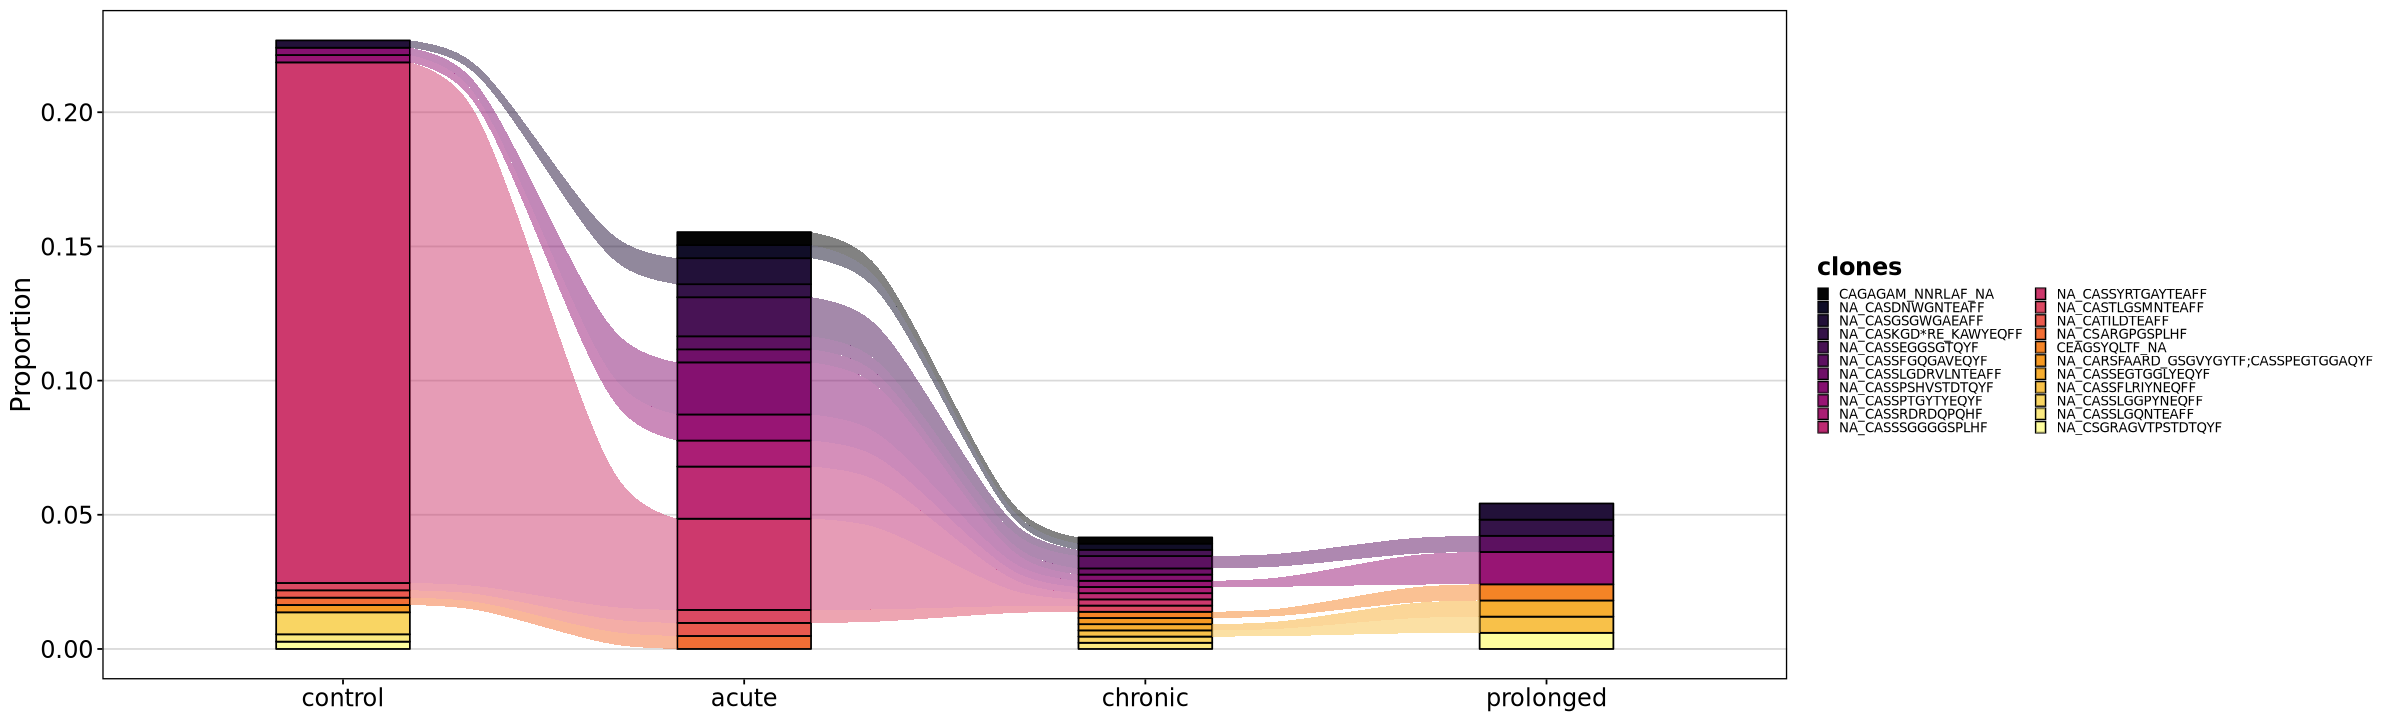

In [33]:
options(repr.plot.width = 20, repr.plot.height = 6, warn = -1)

shared_cond <- do.call(rbind, tcr) %>%
  distinct(CTaa, condition, cond_tissue) %>%
  group_by(CTaa) %>%
  summarise(
    n_conditions = n_distinct(condition),
    conditions = paste(sort(unique(condition)), collapse = ";"),
    .groups = "drop"
  ) %>%
  filter(n_conditions > 1) %>%
  arrange(desc(n_conditions)) %>%
  pull(CTaa)

clonalCompare(tcr, cloneCall = "aa", group.by = "condition", order.by = c("control", "acute", "chronic", "prolonged"), 
              clones = shared_cond) +
theme(text = element_text(size = 16))

## Clonotype frequencies (>2 spots)

### AA clone callign

In [33]:
do.call(rbind, tcr) %>%
    filter(!is.na(CTaa)) %>%
    group_by(CTaa) %>%
    summarise(total_spots = n(),
              n_tissues = n_distinct(tissue),
              n_conditions = n_distinct(condition),
              conditions = paste(sort(unique(condition)), collapse = ";"),
              samples = paste(sort(unique(cond_tissue)), collapse = ";"),
              .groups = "drop") %>%
    filter(total_spots > 2) %>%
    arrange(desc(total_spots))

CTaa,total_spots,n_tissues,n_conditions,conditions,samples
<chr>,<int>,<int>,<int>,<chr>,<chr>
NA_CASSYRTGAYTEAFF,79,2,3,acute;chronic;control,acute_case_2-lung;acute_case_2-lymph-node;chronic_case_1-lymph-node;control_case_2-lymph-node
CVVIPLGGYNKLIF_NA,18,2,1,control,control_case_2-lung;control_case_2-lymph-node
NA_CASSHENQPQHF,18,1,1,chronic,chronic_case_4-lung
NA_CASSPSHVSTDTQYF,6,2,3,acute;chronic;control,acute_case_2-lung;chronic_case_1-lung;control_case_2-lymph-node
NA_CASSPTGYTYEQYF,6,2,4,acute;chronic;control;prolonged,acute_case_2-lung;acute_case_2-lymph-node;chronic_case_1-lymph-node;control_case_2-lymph-node;prolonged_case_5-lymph-node
CVVIPLGGYNKLIF_CASSYRTGAYTEAFF,5,1,1,control,control_case_2-lymph-node
NA_CASSSGGGGSPLHF,5,2,2,acute;chronic,acute_case_2-lung;acute_case_2-lymph-node;chronic_case_1-lymph-node
CALDIPIYSSASKIIF_NA,4,1,1,control,control_case_2-lymph-node
NA_CASGSGWGAEAFF,4,2,3,acute;control;prolonged,acute_case_2-lung;acute_case_2-lymph-node;control_case_2-lymph-node;prolonged_case_5-lymph-node


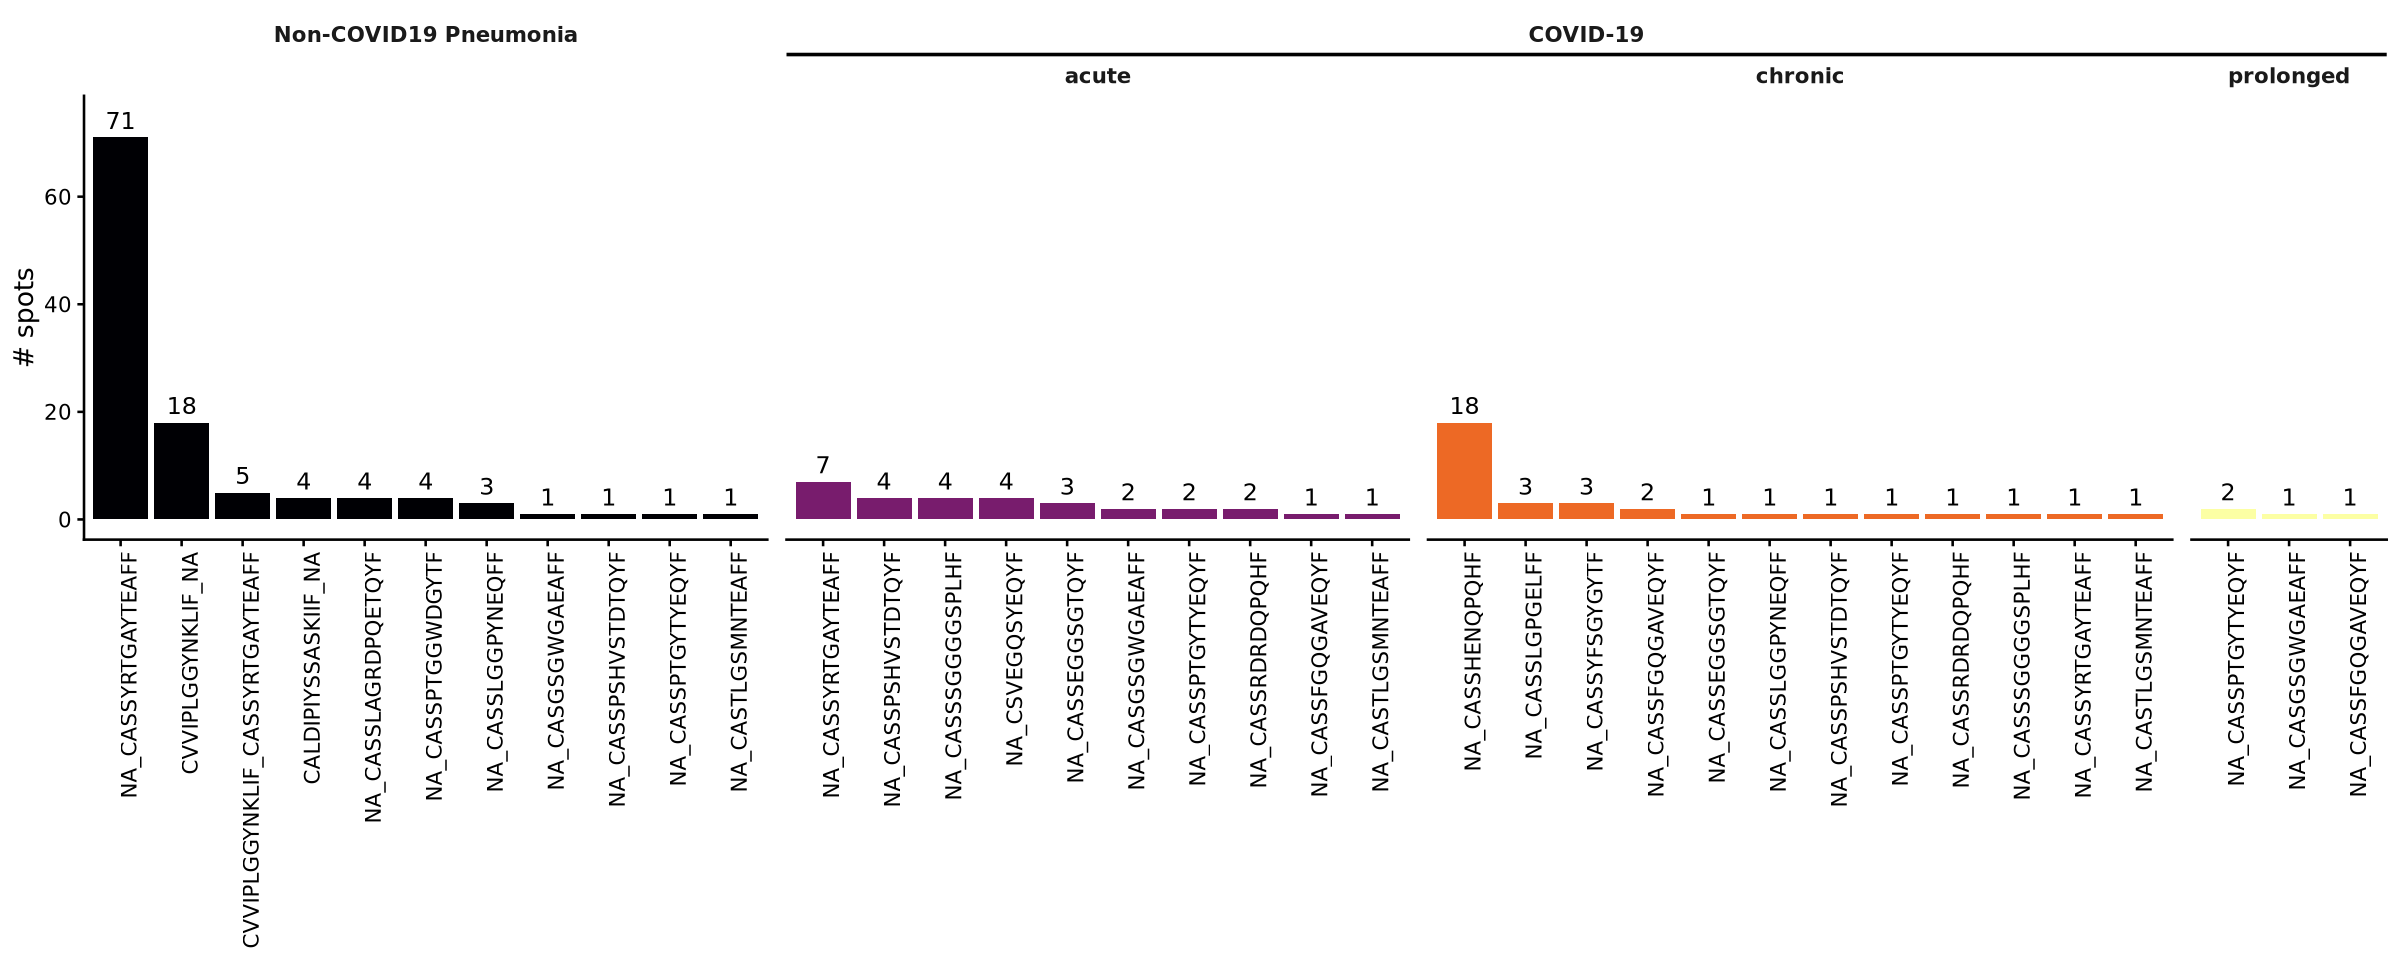

In [38]:
options(repr.plot.width = 20, repr.plot.height = 8, warn = -1)

do.call(rbind, tcr) %>%
    filter(!is.na(CTaa), !is.na(condition)) %>%
    group_by(CTaa) %>%
    mutate(total_spots = n()) %>%
    filter(total_spots > 2) %>%
    #filter(n >= 2) %>%  filter to at least 2 spots in each condition?
    group_by(CTaa, condition, total_spots) %>%
    summarise(freq = n(), .groups = "drop") %>%
    arrange(condition, desc(total_spots)) %>%
    mutate(condition = factor(condition,
                       levels = c("control", "acute", "chronic", "prolonged")),
           disease_group = ifelse(condition == "control", "Non-COVID19 Pneumonia", "COVID-19"),
           disease_group = factor(disease_group, levels = c("Non-COVID19 Pneumonia", "COVID-19")),
           CTaa = reorder_within(CTaa, -freq, condition)) %>%

    ggplot(aes(x = CTaa, y = freq, fill = condition)) +
    geom_bar(stat = "identity") +
    geom_text(aes(label = freq), vjust = -0.5, size = 5) +
    ggh4x::facet_nested(~ disease_group + condition,
                        scales = "free_x", space  = "free_x",
                        labeller = labeller(
      condition = c("control" = "", "acute" = "acute",
                    "chronic" = "chronic", "prolonged" = "prolonged"))) +
    coord_cartesian(ylim = c(0, 75)) +
    scale_x_reordered() +
    scale_fill_manual(values = viridis::inferno(4)) +
    labs(y = "# spots", x = NULL) +
    theme_classic(base_size = 16) +
    theme(strip.background = element_blank(),
          strip.text = element_text(face = "bold"),
          ggh4x.facet.nestline = element_line(linewidth = 1),
          legend.position = "none",
          axis.text.x = element_text(angle = 90, hjust = 1),
          panel.spacing = unit(0.8, "lines"))

### Strict clone calling

In [34]:
do.call(rbind, tcr) %>%
    filter(!is.na(CTstrict)) %>%
    group_by(CTstrict) %>%
    summarise(total_spots = n(),
              n_tissues = n_distinct(tissue),
              n_conditions = n_distinct(condition),
              conditions = paste(sort(unique(condition)), collapse = ";"),
              samples = paste(sort(unique(cond_tissue)), collapse = ";"),
              .groups = "drop") %>%
    filter(total_spots > 2) %>%
    arrange(desc(total_spots))

CTstrict,total_spots,n_tissues,n_conditions,conditions,samples
<chr>,<int>,<int>,<int>,<chr>,<chr>
NA;NA_TRBV6-6*00(265.5).TRBD1*00(35).TRBJ1-1*00(163.9).;TGTGCCAGCAGTTACCGAACAGGGGCATACACTGAAGCTTTCTTT,71,1,1,control,control_case_2-lymph-node
NA;NA_TRBV14*00(275.7)..TRBJ1-5*00(153.9).;TGTGCCAGCAGCCATGAAAATCAGCCCCAGCATTTT,18,1,1,chronic,chronic_case_4-lung
TRAV12-1*00(254.9).TRAJ4*00(198.3).;TGTGTGGTGATTCCCCTCGGTGGCTACAATAAGCTGATTTTT_NA;NA,17,1,1,control,control_case_2-lymph-node
NA;NA_TRBV6-6*00(251.9).TRBD1*00(35).TRBJ1-1*00(151.7).;TGTGCCAGCAGTTACCGAACAGGGGCATACACTGAAGCTTTCTTT,6,1,1,acute,acute_case_2-lymph-node
TRAV12-1*00(254.9).TRAJ4*00(198.3).;TGTGTGGTGATTCCCCTCGGTGGCTACAATAAGCTGATTTTT_TRBV6-6*00(265.5).TRBD1*00(35).TRBJ1-1*00(163.9).;TGTGCCAGCAGTTACCGAACAGGGGCATACACTGAAGCTTTCTTT,5,1,1,control,control_case_2-lymph-node
NA;NA_TRBV27*00(252)..TRBJ2-3*00(147.5).;TGTGCCAGCAGTCCCAGTCACGTATCCACAGATACGCAGTATTTT,4,1,1,acute,acute_case_2-lung
NA;NA_TRBV7-6*00(265.9).TRBD1*00(40).TRBJ1-2*00(127.2).;TGTGCCAGCAGTCCAACAGGGGGATGGGATGGCTACACCTTC,4,1,1,control,control_case_2-lymph-node
"NA;NA_TRBV7-8*00(265).TRBD2*00(29),TRBD1*00(25).TRBJ2-5*00(161.5).;TGTGCCAGCAGCTTAGCGGGCAGGGACCCTCAAGAGACCCAGTACTTC",4,1,1,control,control_case_2-lymph-node
TRAV6*00(267).TRAJ3*00(216.4).;TGTGCTCTAGACATCCCGATTTACAGCAGTGCTTCCAAGATAATCTTT_NA;NA,4,1,1,control,control_case_2-lymph-node


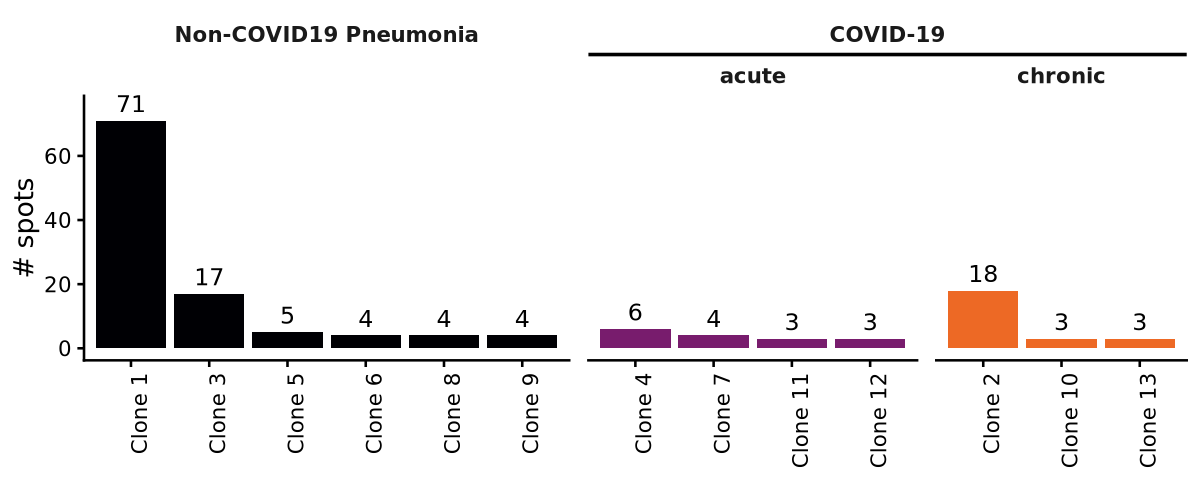

In [38]:
options(repr.plot.width = 10, repr.plot.height = 4, warn = -1)

do.call(rbind, tcr) %>%
    filter(!is.na(CTstrict), !is.na(condition)) %>%
    add_count(CTstrict, name = "total_spots") %>%
    filter(total_spots > 2) %>%
    count(CTstrict, condition, total_spots, name = "freq") %>%
    left_join(distinct(., CTstrict, total_spots) %>%
              arrange(desc(total_spots)) %>%
              mutate(Clone = paste0("Clone ", row_number())),
              by = c("CTstrict", "total_spots")) %>%
    mutate(condition = factor(condition,
                              levels = c("control", "acute", "chronic", "prolonged")),
           disease_group = factor(ifelse(condition == "control", "Non-COVID19 Pneumonia", "COVID-19"),
                                  levels = c("Non-COVID19 Pneumonia", "COVID-19")),
           Clone = reorder_within(Clone, -freq, condition)) %>%
    ggplot(aes(x = Clone, y = freq, fill = condition)) +
    geom_bar(stat = "identity") +
    geom_text(aes(label = freq), vjust = -0.5, size = 5) +
    ggh4x::facet_nested(~ disease_group + condition,
                        scales = "free_x", space  = "free_x",
    labeller = labeller(
        condition = c("control" = "","acute" = "acute", "chronic" = "chronic", "prolonged" = "prolonged"))) +
    coord_cartesian(ylim = c(0, 75)) +
    scale_x_reordered() +
    scale_fill_manual(values = viridis::inferno(4)) +
    labs(y = "# spots", x = NULL) +
    theme_classic(base_size = 16) +
    theme(strip.background = element_blank(),
          strip.text = element_text(face = "bold"),
          ggh4x.facet.nestline = element_line(linewidth = 1),
          legend.position = "none",
          axis.text.x = element_text(angle = 90, hjust = 1),
          panel.spacing = unit(0.8, "lines"))